# Final Assignment – FinTech Course
## Credit Card Default Prediction (Taiwan, 2005)

**Data**：dataset3.csv（Default of Credit Card Clients）

**Objectives**:
- Build a default prediction classifier using Random Forest and XGBoost
- Perform feature selection using Lasso before modeling, and compare performance
- Analyze the most significant drivers of default
- Address the issue of data imbalance

## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz, export_text
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 2. Data Load

In [2]:
df = pd.read_csv('Dataset3.csv', sep=';')
print("Data shape:", df.shape)

df.head()

Data shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 3. Data Analysis

In [3]:
print(df.info())
print("\nStatistics on Missing Values:")
print(df.isnull().sum())
print("\nDistribution of the target variable (balanced or not):")
print(df['default.payment.next.month'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

### Imbalance Analysis

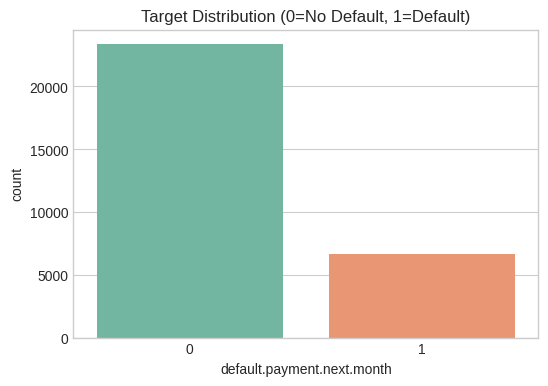

Default num: 6636;
No default num: 23364;
Default Rate: 22.12% — data unbalanced


In [4]:
# Imbalanced Analysis
plt.figure(figsize=(6,4))
sns.countplot(x='default.payment.next.month', data=df, palette='Set2')
plt.title('Target Distribution (0=No Default, 1=Default)')
plt.show()

target_counts = df['default.payment.next.month'].value_counts()
print(f"Default num: {target_counts[1]};\nNo default num: {target_counts[0]};")

default_rate = df['default.payment.next.month'].mean()
print(f"Default Rate: {default_rate:.2%} — data{' unbalanced' if default_rate < 0.3 else ' balanced'}")

## 4. Data Preprocessing

In [5]:
X = df.drop(['ID', 'default.payment.next.month'], axis=1)
y = df['default.payment.next.month']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of training set: {X_train.shape}, Shape of testing set: {X_test.shape}")

Shape of training set: (24000, 23), Shape of testing set: (6000, 23)


## 5. Baseline：Random Forest + XGBoost

In [6]:
# Random Forest hyperparameter
rf_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [5, 10, 15],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf': [2, 4, 8]
}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
# rf_best is a model with best parameter trained by RandomForestClassifier
rf_best = rf_grid.best_estimator_

Best RF params: {'max_depth': 15, 'min_samples_leaf': 8, 'min_samples_split': 3, 'n_estimators': 400}


In [7]:
# XGBoost hyperparameter
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print("Best XGB params:", xgb_grid.best_params_)
# xgb_best is a model with best parameter trained by XGBClassifier
xgb_best = xgb_grid.best_estimator_

Best XGB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


In [8]:
# Evaluating function
def evaluate_model(model, X_test, y_test, name, threshold = 0.5):
    # y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    print(f"\n=== {name} ===")
    print(f"AUC: {auc:.4f}")
    print(f"F1:  {f1:.4f}")
    print(classification_report(y_test, y_pred))
    return auc, f1

rf_auc, rf_f1 = evaluate_model(rf_best, X_test, y_test, "Random Forest (Baseline)")
xgb_auc, xgb_f1 = evaluate_model(xgb_best, X_test, y_test, "XGBoost (Baseline)")


=== Random Forest (Baseline) ===
AUC: 0.7733
F1:  0.4597
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000


=== XGBoost (Baseline) ===
AUC: 0.7793
F1:  0.4700
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



## 6. Lasso Feature Selection

In [9]:
# Lasso feature selection
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

# Select non-zero features
selected_features = X_train.columns[lasso.coef_ != 0]
print(f"Number of Selected features: {len(selected_features)}")
print("Selected features:", selected_features.tolist())

# Training model with selected feature
X_train_lasso = X_train[selected_features]
X_test_lasso = X_test[selected_features]

Number of Selected features: 16
Selected features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_6', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [10]:
# retraining RF and XGB
rf_lasso_params = {
    'n_estimators': [200, 300, 400],
    'max_depth': [5, 10, 15],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf': [2, 4, 8]
}
rf_lasso = RandomForestClassifier(random_state=42)
rf_lasso_grid = GridSearchCV(rf_lasso, rf_lasso_params, cv=3, scoring='roc_auc', n_jobs=-1)
rf_lasso_grid.fit(X_train_lasso, y_train)

print("Best RF params:", rf_lasso_grid.best_params_)
# rf_best is a model with best parameter trained by RandomForestClassifier
rf_lasso_best = rf_lasso_grid.best_estimator_

Best RF params: {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 3, 'n_estimators': 400}


In [11]:
xgb_lasso_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_lasso = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_lasso_grid = GridSearchCV(xgb_lasso, xgb_lasso_params, cv=3, scoring='roc_auc', n_jobs=-1)
xgb_lasso_grid.fit(X_train_lasso, y_train)

print("Best XGB params:", xgb_lasso_grid.best_params_)
# xgb_best is a model with best parameter trained by XGBClassifier
xgb_lasso_best = xgb_lasso_grid.best_estimator_

Best XGB params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


In [12]:
rf_lasso_auc, rf_lasso_f1 = evaluate_model(rf_lasso_best, X_test_lasso, y_test, "Random Forest (Lasso)")
xgb_lasso_auc, xgb_lasso_f1 = evaluate_model(xgb_lasso_best, X_test_lasso, y_test, "XGBoost (Lasso)")


=== Random Forest (Lasso) ===
AUC: 0.7740
F1:  0.4612
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000


=== XGBoost (Lasso) ===
AUC: 0.7784
F1:  0.4645
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



### Feature Importance and Driver Analysis

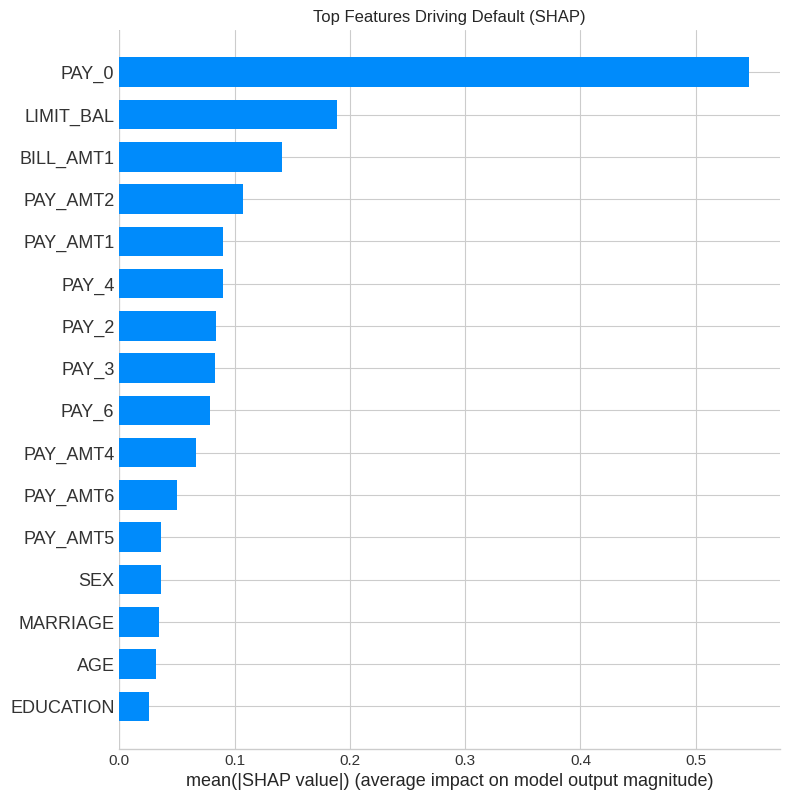

In [13]:
# SHAP Explaination（by xgb_lasso）
explainer = shap.TreeExplainer(xgb_lasso_best)
shap_values = explainer.shap_values(X_test_lasso)

shap.summary_plot(shap_values, X_test_lasso, plot_type="bar", show=False)
plt.title("Top Features Driving Default (SHAP)")
plt.show()

## 7. Solutions for Data Imbalance (SMOTE)

### Class Weighting

In [14]:
# Random Forest hyperparameter
rf_CW = RandomForestClassifier(**rf_lasso_grid.best_params_, random_state=42, class_weight='balanced')
rf_CW.fit(X_train_lasso, y_train)

xgb_CW = XGBClassifier(**xgb_lasso_grid.best_params_, random_state=42, eval_metric='logloss', scale_pos_weight = target_counts[0]/target_counts[1])
xgb_CW.fit(X_train_lasso, y_train)

rf_CW_auc, rf_CW_f1 = evaluate_model(rf_CW, X_test_lasso, y_test, "Random Forest (Lasso)")
xgb_CW_auc, xgb_CW_f1 = evaluate_model(xgb_CW, X_test_lasso, y_test, "XGBoost (Lasso)")


=== Random Forest (Lasso) ===
AUC: 0.7766
F1:  0.5444
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      4673
           1       0.51      0.58      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.80      0.79      0.79      6000


=== XGBoost (Lasso) ===
AUC: 0.7781
F1:  0.5369
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4673
           1       0.48      0.61      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000



### SMOTE

In [15]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_lasso, y_train)

# Training with data processed by SMOTE
xgb_smote = XGBClassifier(**xgb_lasso_grid.best_params_, random_state=42, eval_metric='logloss', scale_pos_weight = target_counts[0]/target_counts[1])
xgb_smote.fit(X_train_smote, y_train_smote)
xgb_smote_auc, xgb_smote_f1 = evaluate_model(xgb_smote, X_test_lasso, y_test, "XGBoost(Lasso) + SMOTE")


=== XGBoost(Lasso) + SMOTE ===
AUC: 0.7480
F1:  0.4358
              precision    recall  f1-score   support

           0       0.91      0.42      0.57      4673
           1       0.29      0.85      0.44      1327

    accuracy                           0.51      6000
   macro avg       0.60      0.63      0.50      6000
weighted avg       0.77      0.51      0.54      6000



## 8. Threshold Optimization

In [17]:
def find_best_threshold(model, X_val, y_val):
    # Finding the Optimal Threshold for Macro F1 Based on the PR Curve
    y_proba = model.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)

    best_f1 = 0
    best_thresh = 0.5

    for p, r, t in zip(precisions, recalls, thresholds):
        if p + r == 0:
            continue
        f1 = 2 * (p * r) / (p + r)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t

    return best_thresh, best_f1

# Optimizing with XGBoost(Lasso)
best_thresh, best_f1 = find_best_threshold(xgb_lasso_best, X_train_lasso, y_train)
xgb_lasso_threshold_auc, xgb_lasso_threshold_f1 = evaluate_model(xgb_lasso_best, X_test_lasso, y_test, "XGBoost(Lasso) + Thresholding", best_thresh)

print(f"Best Threshold: {best_thresh:.4f}（defalut 0.5）")


=== XGBoost(Lasso) + Thresholding ===
AUC: 0.7784
F1:  0.5399
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.52      0.57      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000

Best Threshold: 0.2597（defalut 0.5）


## 9. Summary


In [19]:
# Perfomance rank
results = pd.DataFrame({
    'Model': ['RF Baseline', 'XGB Baseline', 'RF Lasso', 'XGB Lasso', 'XGBoost(Lasso) + CW', 'XGBoost(Lasso) + SMOTE', 'XGBoost(Lasso) + Thresholding'],
    'AUC': [rf_auc, xgb_auc, rf_lasso_auc, xgb_lasso_auc, xgb_CW_auc, xgb_smote_auc, xgb_lasso_threshold_auc],
    'F1': [rf_f1, xgb_f1, rf_lasso_f1, xgb_lasso_f1, xgb_CW_f1, xgb_smote_f1, xgb_lasso_threshold_f1]
})
print(results.sort_values('AUC', ascending=False))

                           Model       AUC        F1
1                   XGB Baseline  0.779259  0.469956
6  XGBoost(Lasso) + Thresholding  0.778433  0.539899
3                      XGB Lasso  0.778433  0.464478
4            XGBoost(Lasso) + CW  0.778110  0.536908
2                       RF Lasso  0.773971  0.461160
0                    RF Baseline  0.773315  0.459725
5         XGBoost(Lasso) + SMOTE  0.747969  0.435823
